In [1]:
# Step 1 Import The Libraries
import pandas as pd
import matplotlib.pyplot as plt

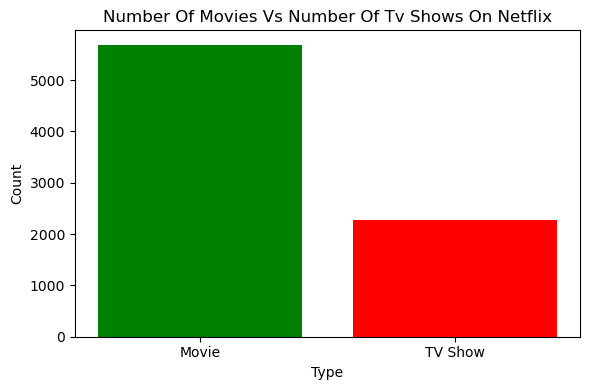

In [7]:
# Number Of Movies Vs Number Of TV Shows Bar Chart
# Step 2 Load The Data 
df = pd.read_csv('netflix_titles.csv')

# Step 3 Clean Data 
df = df.dropna(subset=['type', 'release_year', 'rating', 'country', 'duration'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=['green', 'red'])
plt.title('Number Of Movies Vs Number Of Tv Shows On Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvShows.png')
plt.show()

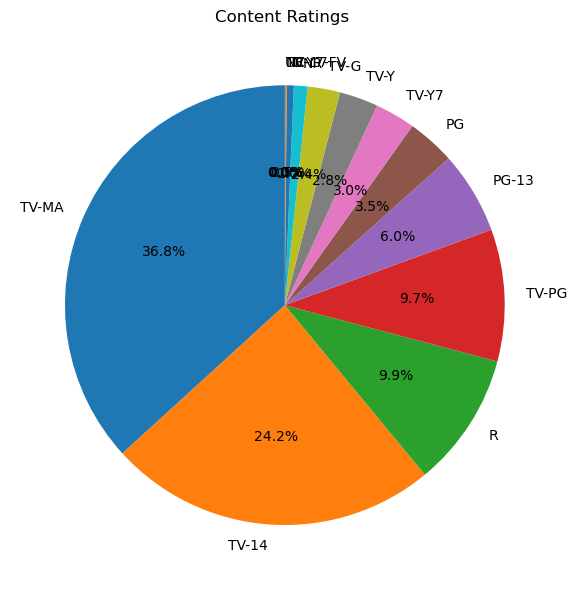

In [12]:
# Content Rating 

rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Content Ratings ')
plt.tight_layout()
plt.savefig('Content_Ratings.png')

plt.show()

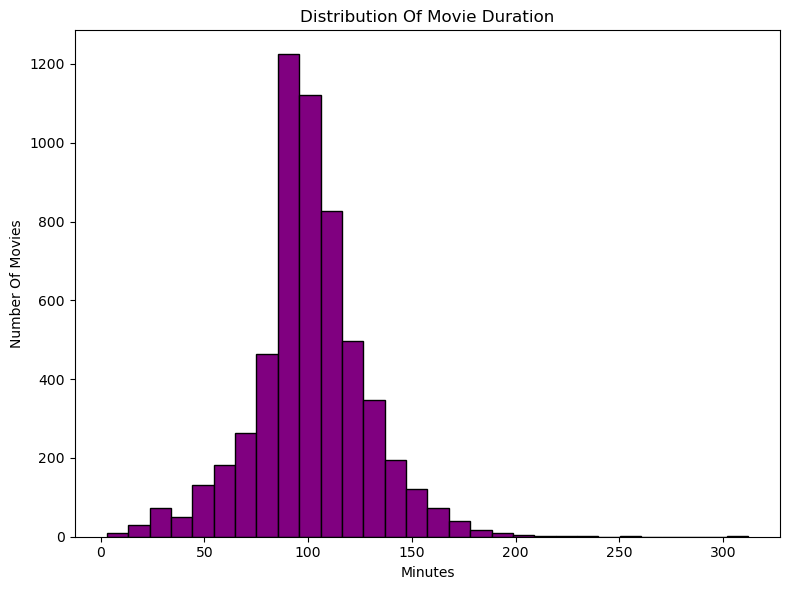

In [14]:
# Duration Of Movies Histogram

movie_df = df[df['type']=='Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min', '').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins=30,color='purple', edgecolor='black')
plt.title('Distribution Of Movie Duration')
plt.xlabel('Minutes')
plt.ylabel('Number Of Movies')
plt.tight_layout()
plt.savefig('movie_duration_histogram.png')

plt.show()

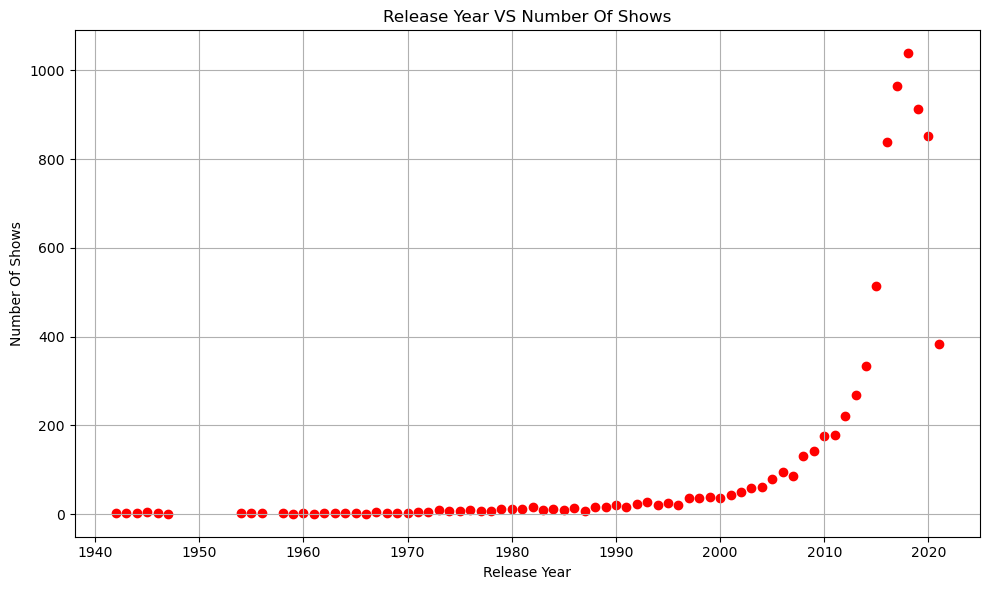

In [17]:
# Release Year Shows Scatter Plot

release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index, release_counts.values, color='red')
plt.title('Release Year VS Number Of Shows')
plt.xlabel('Release Year')
plt.ylabel('Number Of Shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.grid(True)

plt.show()

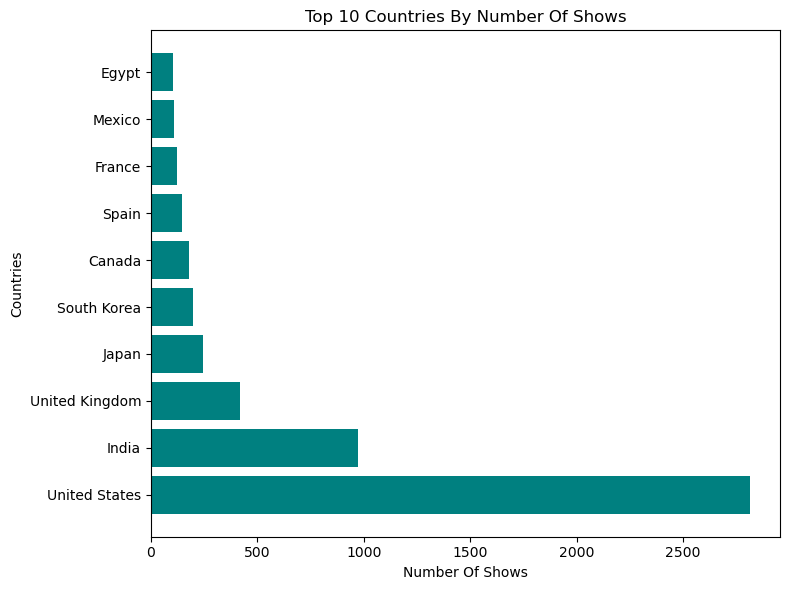

In [20]:
# Horizontal Bar Chart

country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color='teal')
plt.title('Top 10 Countries By Number Of Shows')
plt.xlabel('Number Of Shows')
plt.ylabel('Countries')
plt.tight_layout()
plt.savefig('top10_countries_byShows.png')

plt.show()

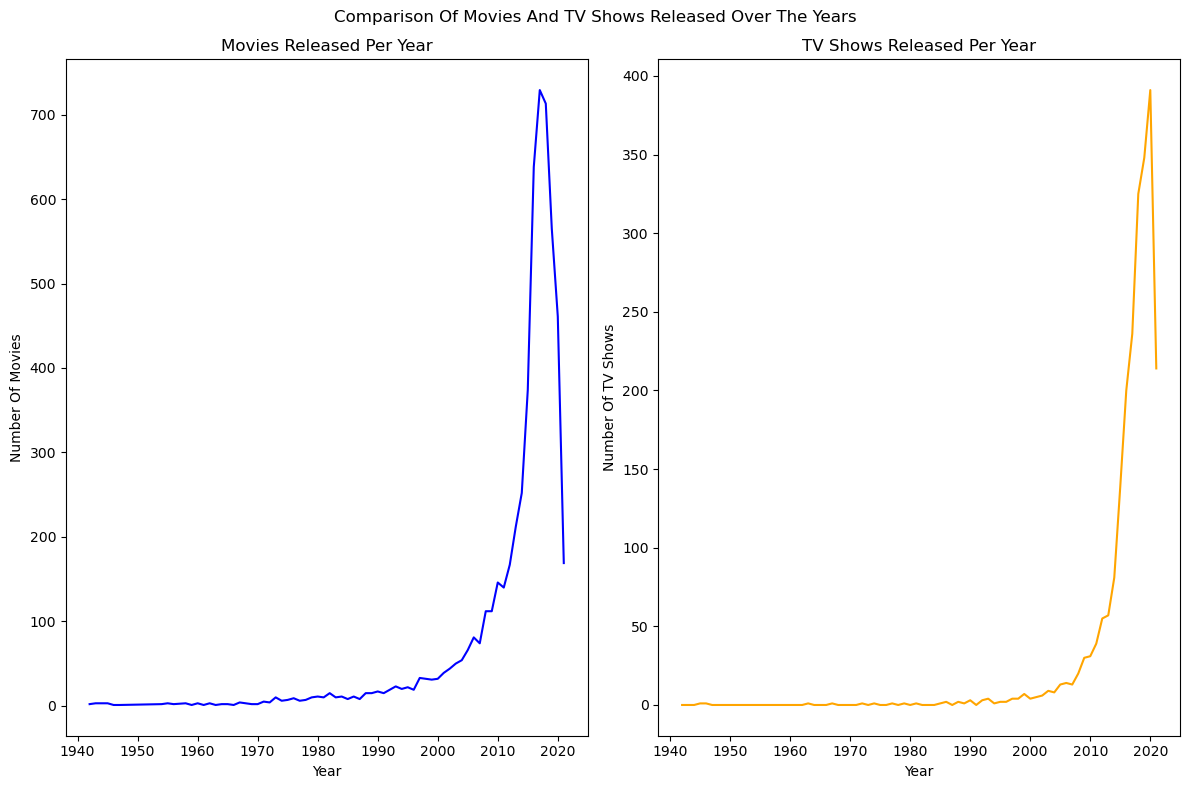

In [26]:
# Subplot Of Movies And TV Shows By Year 

content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1,2,figsize=(12,8))

#First Subplot Movies 
ax[0].plot(content_by_year.index, content_by_year['Movie'], color='blue')
ax[0].set_title('Movies Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number Of Movies')

#Second Subplot Of TV Shows
ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='orange')
ax[1].set_title('TV Shows Released Per Year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number Of TV Shows')

fig.suptitle('Comparison Of Movies And TV Shows Released Over The Years')

plt.tight_layout()
plt.savefig('movies_tvShows_comparison.png')

plt.show()